<a href="https://colab.research.google.com/github/mirdanish6594/CO2-Capture-ML/blob/main/06_Feature_Selection_and_Final_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Selection and Final Machine Learning Modeling

## Objective

This notebook performs the final machine learning modeling stage.

Steps included:

1. Load augmented dataset
2. Remove redundant features
3. Analyze correlations
4. Select informative descriptors
5. Train multiple ML models
6. Evaluate model performance
7. Generate visualizations for analysis

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_PATH = '/content/drive/MyDrive/CO2-Capture-ML/'

DATA_PATH = PROJECT_PATH + 'Data/Processed/Augmented_Data.csv'

df = pd.read_csv(DATA_PATH)

print("Dataset shape:")
print(df.shape)

df.head()

Dataset shape:
(879, 43)


,temperature_k,CO2 Loading (mol/mol_alk),PCO2* (Pa),Target -> kg′ (mol/s·Pa·m²),conc_aep_m,conc_amp_m,conc_dga_m,conc_dmpz_m,conc_eda_m,conc_hep_m,...,NumAromaticHeterocycles,NumValenceElectrons,LabuteASA,MolMR,Chi0v,Chi1v,Chi2v,Kappa1,Kappa2,Kappa3
0,332.307021,0.386960,896.373227,1.470000e-06,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,26.0,25.238318,16.1402,2.438777,1.224476,0.512282,3.920000,2.920000,1.920000
1,373.150000,0.063000,6530.000000,2.530000e-06,0.0,0.0,0.0,0.0,0.0,7.7,...,0.0,44.0,45.903852,33.1964,5.112884,3.115355,1.849335,6.960000,5.960000,5.960000
2,374.737183,0.131455,30339.227705,6.700000e-07,0.0,0.0,0.0,0.0,0.0,7.7,...,0.0,44.0,45.903852,33.1964,5.112884,3.115355,1.849335,6.960000,5.960000,5.960000
3,374.693934,0.372540,19293.602409,1.400000e-06,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,26.0,25.238318,16.1402,2.438777,1.224476,0.512282,3.920000,2.920000,1.920000
4,353.150000,0.253000,9720.000000,1.370000e-06,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,42.0,44.502884,30.3667,4.775641,2.786776,2.053276,5.064509,2.284555,1.450252


## Clean Column Names

In [ ]:
df.columns = (
    df.columns
    .str.replace("\u200b","",regex=True)
    .str.replace("∗","*")
    .str.replace("′","'")
    .str.strip()
)

print(df.columns.tolist())

['temperature_k', 'CO2 Loading (mol/mol_alk)', 'PCO2* (Pa)', "Target -> kg' (mol/s·Pa·m²)", 'conc_aep_m', 'conc_amp_m', 'conc_dga_m', 'conc_dmpz_m', 'conc_eda_m', 'conc_hep_m', 'conc_mapa_m', 'conc_mdea_m', 'conc_mea_m', 'conc_mpz_m', 'conc_pe_m', 'conc_pz_m', 'MolWt', 'ExactMolWt', 'MolLogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 'RingCount', 'HeavyAtomCount', 'FractionCSP3', 'NOCount', 'NHOHCount', 'NumAliphaticRings', 'NumAromaticRings', 'NumAliphaticCarbocycles', 'NumAromaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAromaticHeterocycles', 'NumValenceElectrons', 'LabuteASA', 'MolMR', 'Chi0v', 'Chi1v', 'Chi2v', 'Kappa1', 'Kappa2', 'Kappa3']


# IDENTIFY TARGET COLUMN

In [ ]:
target_candidates = [c for c in df.columns if "kg" in c.lower()]

print("Possible target columns:", target_candidates)

TARGET = target_candidates[0]

print("Using target:", TARGET)

Possible target columns: ["Target -> kg' (mol/s·Pa·m²)"]
Using target: Target -> kg' (mol/s·Pa·m²)


# Log Transform Target

In [ ]:
y_raw = df[TARGET]

# log transform
y = np.log10(y_raw)

print("Target statistics (log scale):")

print(y.describe())

Target statistics (log scale):
count    870.000000
mean      -5.884797
std        0.469605
min       -7.096910
25%       -6.193820
50%       -5.853872
75%       -5.581699
max       -4.087778
Name: Target -> kg' (mol/s·Pa·m²), dtype: float64


# Define Feature Matrix

In [ ]:
drop_cols = [TARGET, "amine"]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (879, 42)


# REMOVE NAN VALUES

In [ ]:
mask = (~X.isna().any(axis=1)) & (~y.isna())

X = X[mask]
y = y[mask]

print("Clean dataset shape:", X.shape)

Clean dataset shape: (870, 42)


# CORRELATION HEATMAP

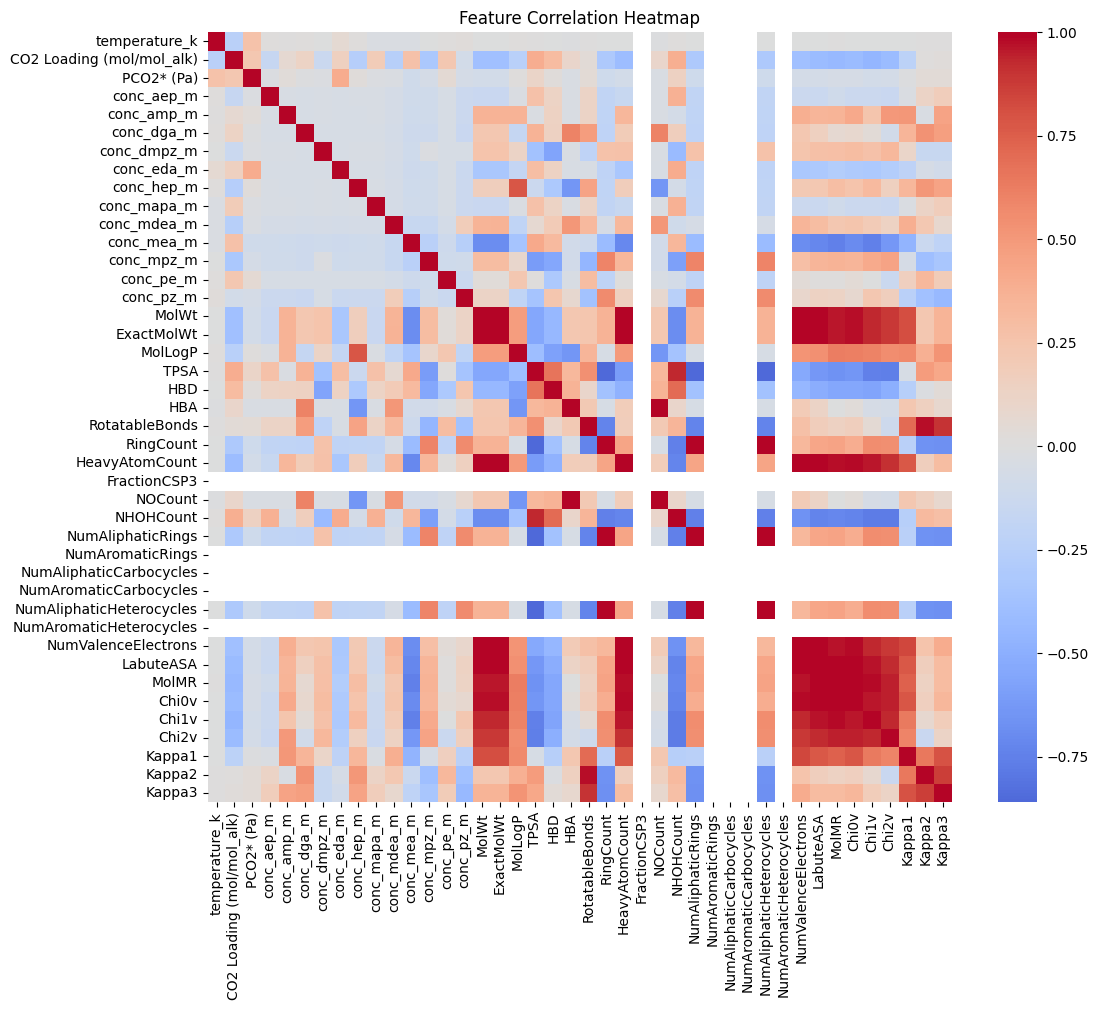

In [ ]:
plt.figure(figsize=(12,10))

corr = X.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


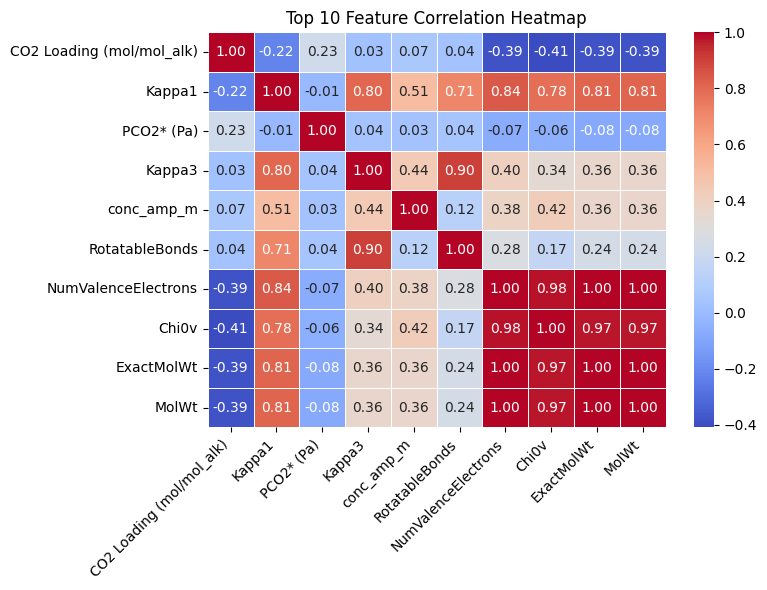

In [ ]:
# Select top correlated features with target (y)
corr_target = X.corrwith(y).abs().sort_values(ascending=False)

top_features = corr_target.head(10).index

plt.figure(figsize=(8,6))

sns.heatmap(
    X[top_features].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Top 10 Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 🔴 protect physically important features
protected = ['PCO2 (Pa)', 'temperature_k', 'CO2 Loading (mol/mol_alk)']

to_drop = []

for col in upper.columns:
    if col in protected:
        continue
    if any(upper[col] > 0.95):
        to_drop.append(col)

print("Dropping:", to_drop)

X = X.drop(columns=to_drop)

Dropping: []


# Remove highly correlated features

In [ ]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Removing", len(to_drop), "correlated features")

X = X.drop(columns=to_drop)

print("Remaining features:", X.shape)

Removing 0 correlated features
Remaining features: (870, 26)


# Train Test Split

In [ ]:
y_series = pd.Series(y, index=X.index)

high_mask = y_series > y_series.median()
low_mask = y_series <= y_series.median()

high = X.loc[high_mask]
low = X.loc[low_mask]

In [ ]:
# Remove constant columns
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]

print("Removing constant columns:", constant_cols)

X = X.drop(columns=constant_cols)

Removing constant columns: ['FractionCSP3', 'NumAromaticRings', 'NumAliphaticCarbocycles', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles']


In [ ]:
for col in X.columns:
    if X[col].std() == 0:
        continue  # skip constant columns safely

    corr = np.corrcoef(X[col], y)[0,1]

    if not np.isnan(corr) and abs(corr) > 0.95:
        print(f"⚠️ Possible leakage: {col} → corr = {corr:.3f}")

# Feature Scaling

In [ ]:
# For tree models
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

# For neural network ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest Model

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Evaluate Random Forest

In [ ]:
print("Random Forest")

print("R2:", r2_score(y_test, rf_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("MAE:", mean_absolute_error(y_test, rf_pred))

Random Forest
R2: 0.9672866375267708
RMSE: 0.08412176394748859
MAE: 0.05282362960403765


# XGBoost Model

In [ ]:
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

# Evaluate XGBoost

In [ ]:
print("XGBoost")

print("R2:", r2_score(y_test, xgb_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("MAE:", mean_absolute_error(y_test, xgb_pred))

XGBoost
R2: 0.9853540056828749
RMSE: 0.056286624980350614
MAE: 0.033370522226086156


# Neural Network Model

In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64,32),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

mlp_pred = mlp.predict(X_test_scaled)

# Evaluate Neural Network

In [ ]:
print("Neural Network")

print("R2:", r2_score(y_test, mlp_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, mlp_pred)))

print("MAE:", mean_absolute_error(y_test, mlp_pred))

Neural Network
R2: 0.9059377261804482
RMSE: 0.1426440018614449
MAE: 0.10078178991455501


In [ ]:
# correct version
y_train_shuffled = np.random.permutation(y_train)

xgb.fit(X_train, y_train_shuffled)

print("R2 with shuffled target:",
      r2_score(y_test, xgb.predict(X_test)))

R2 with shuffled target: -0.45097772988603135


# Predicted vs Actual Plot

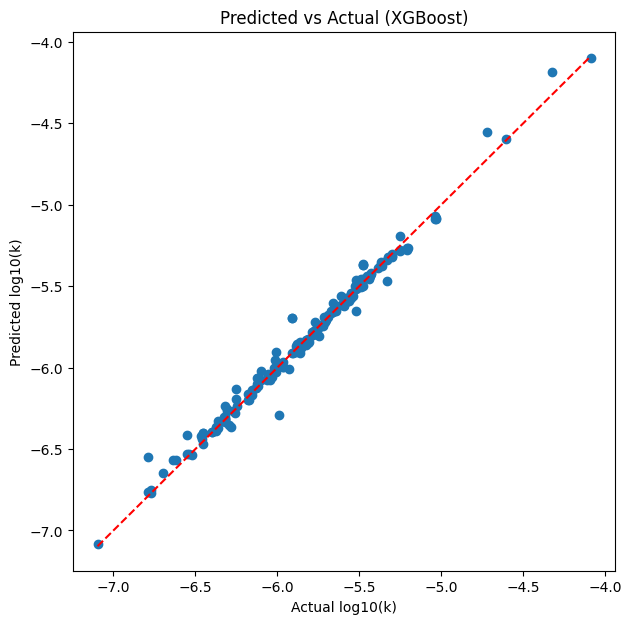

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, xgb_pred)

plt.xlabel("Actual log10(k)")

plt.ylabel("Predicted log10(k)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Predicted vs Actual (XGBoost)")

plt.show()

# Feature Importance

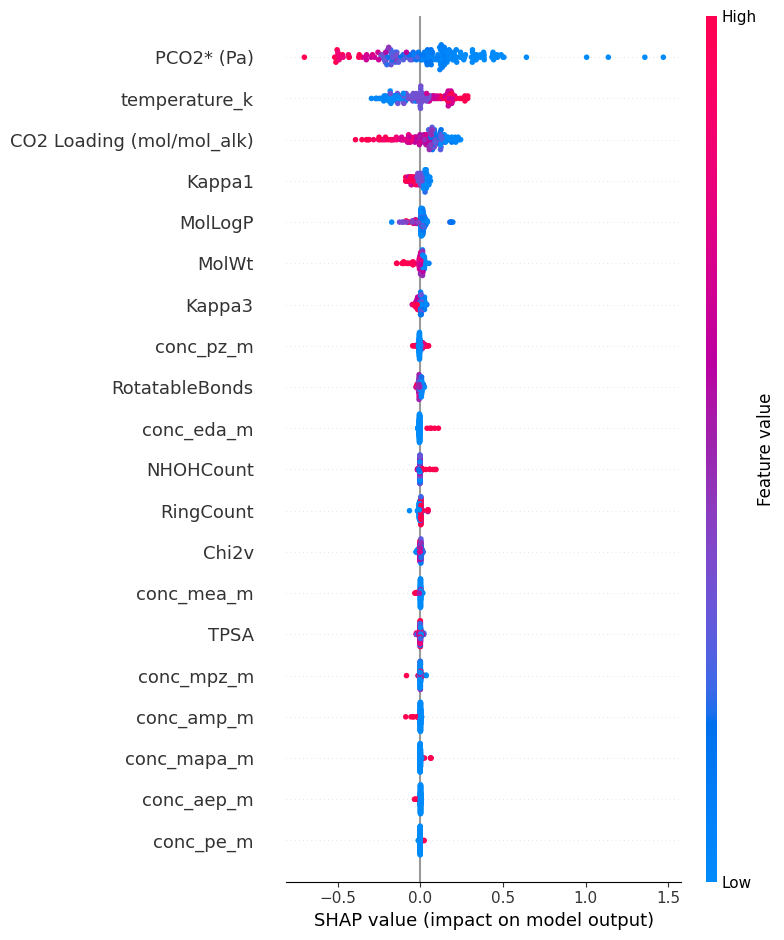

In [ ]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

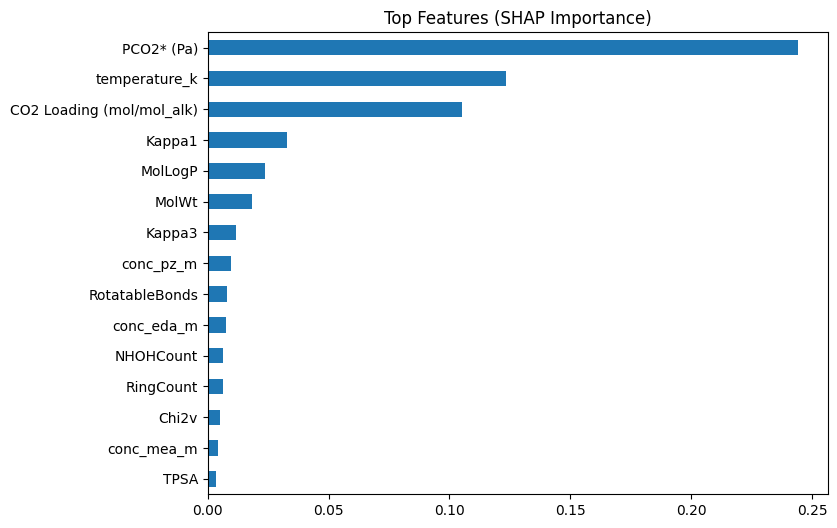

In [ ]:
shap_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

shap_importance.head(15).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Top Features (SHAP Importance)")
plt.show()

### Interpretation of Top 15 Important Features

The feature importance analysis from the trained model highlights the variables that most strongly influence the predicted **CO₂ absorption rate constant (log₁₀(k))**. These include both **molecular descriptors** of the amines and **process variables**, indicating that absorption kinetics depend on a combination of **molecular structure and operating conditions**.

**Top Features and Their Significance**

- **MolLogP** – Represents molecular hydrophobicity; affects solvent–CO₂ interactions and accessibility of reactive sites.
- **NHOHCount** – Number of hydrogen bond donors; influences hydrogen bonding and stabilization of reaction intermediates.
- **Kappa1** – Molecular shape descriptor capturing structural topology and molecular complexity.
- **PCO₂ (Pa)** – Partial pressure of CO₂; determines the thermodynamic driving force for absorption.
- **RingCount** – Number of rings in the molecular structure; affects rigidity and steric hindrance near reactive groups.
- **Kappa3** – Higher-order molecular shape descriptor related to molecular geometry.
- **RotatableBonds** – Indicates molecular flexibility which may influence reactivity with CO₂.
- **conc_eda_m** – Concentration of EDA in the solvent mixture affecting the availability of reactive amine groups.
- **CO₂ Loading (mol/mol_alk)** – Represents solvent saturation level and available reaction capacity.
- **MolWt** – Molecular weight influencing molecular size and diffusion behavior.
- **temperature_k** – Reaction temperature affecting kinetics according to Arrhenius behavior.
- **conc_mapa_m** – MAPA concentration contributing to solvent composition and reactivity.
- **conc_amp_m** – AMP concentration affecting overall solvent performance.
- **TPSA** – Topological polar surface area reflecting molecular polarity and interaction potential with CO₂.
- **conc_pe_m** – PE concentration influencing the reactive composition of the solvent system.

**Key Insight**

The importance of both **molecular descriptors** and **process conditions** suggests that the machine learning model captures meaningful **physico-chemical relationships governing CO₂ absorption kinetics**.